# Q1: Total Least Squares & RANSAC Line Fitting


**Goal:**  
- **(a)** Fit a line to `Line 1` using **Total Least Squares (TLS)** via SVD  
- **(b)** Extract all **three lines** from the combined noisy point cloud using **RANSAC**

### Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=6, suppress=True)

### Load Dataset

In [2]:
# Adjust path if running locally
DATA_PATH = 'lines.csv'   # place the CSV in the same folder, or update path

data = np.genfromtxt(DATA_PATH, delimiter=',')

x1, x2, x3 = data[:, 0], data[:, 1], data[:, 2]
y1, y2, y3 = data[:, 3], data[:, 4], data[:, 5]

print(f'Dataset loaded — {len(x1)} points per line, 3 lines total')

Dataset loaded — 100 points per line, 3 lines total


---
## Part (a): Total Least Squares via SVD

TLS minimises the **perpendicular** distances from points to the fitted line  
(unlike ordinary least squares which minimises vertical residuals).  

**Algorithm:**  
1. Centre the data: subtract the mean  
2. Compute SVD of the centred data matrix  
3. The normal to the best-fit line is the **right singular vector** corresponding to the **smallest singular value**  
4. Recover intercept so the line passes through the centroid

In [3]:
def fit_tls(x_pts, y_pts):
    """
    Total Least Squares line fit via SVD.
    Returns (a, b, c) for  ax + by + c = 0  (unit normal: a²+b²=1).
    """
    cx, cy = np.mean(x_pts), np.mean(y_pts)
    X = np.column_stack([x_pts - cx, y_pts - cy])
    _, _, Vt = np.linalg.svd(X)
    a, b = Vt[-1]               # normal from smallest singular value
    c = -(a * cx + b * cy)      # line passes through centroid
    return a, b, c

In [4]:
a, b, c = fit_tls(x1, y1)

print('TLS result for Line 1')
print(f'  Line equation : {a:.6f}·x + {b:.6f}·y + {c:.6f} = 0')
if abs(b) > 1e-9:
    m = -a / b
    q = -c / b
    print(f'  Slope-intercept: y = {m:.4f}x + ({q:.4f})')

TLS result for Line 1
  Line equation : 0.773562·x + -0.633721·y + -3.794192 = 0
  Slope-intercept: y = 1.2207x + (-5.9872)


Saved → q1a_tls_line1.png


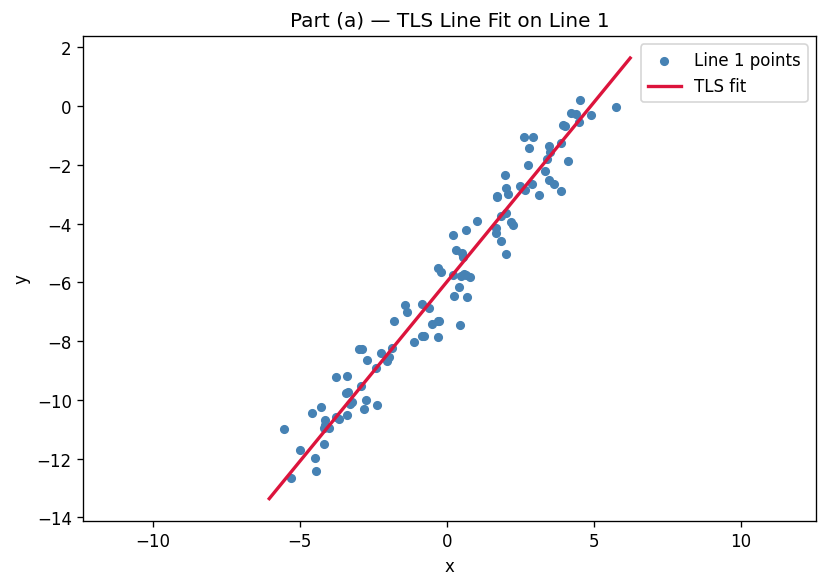

In [5]:
# ── Part (a) Visualization: TLS fit on Line 1 ──
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1, color='steelblue', s=20, label='Line 1 points')

x_range = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 300)
if abs(b) > 1e-9:
    y_line = (-a * x_range - c) / b
    ax.plot(x_range, y_line, color='crimson', linewidth=2, label='TLS fit')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Part (a) — TLS Line Fit on Line 1')
ax.legend(); ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig('q1a_tls_line1.png', dpi=150)
print('Saved → q1a_tls_line1.png')
plt.show()

---
## Part (b): RANSAC — Extracting Three Lines

**Algorithm for each line:**  
1. Randomly sample 2 points  
2. Fit a TLS line through them  
3. Count inliers (points within `threshold` perpendicular distance)  
4. Repeat for `n_iter` iterations; keep the hypothesis with the most inliers  
5. Refit TLS on all inliers of the best hypothesis  

**Sequential extraction:** After finding a line, remove its inliers and repeat on the remaining points.

In [6]:
def perp_distance(a, b, c, x_pts, y_pts):
    """Perpendicular distance from each point to line ax+by+c=0 (unit normal)."""
    return np.abs(a * x_pts + b * y_pts + c)


def ransac_line(x_pts, y_pts, n_iter=1500, threshold=0.5, seed=None):
    """
    RANSAC for a single line.
    Returns best (a, b, c) and boolean inlier mask.
    """
    rng = np.random.default_rng(seed)
    n = len(x_pts)
    best_mask  = np.zeros(n, dtype=bool)
    best_count = 0

    for _ in range(n_iter):
        idx = rng.choice(n, size=2, replace=False)
        a, b, c = fit_tls(x_pts[idx], y_pts[idx])
        dist    = perp_distance(a, b, c, x_pts, y_pts)
        inliers = dist < threshold
        if inliers.sum() > best_count:
            best_count = inliers.sum()
            best_mask  = inliers

    # Refit TLS on consensus set
    a_f, b_f, c_f = fit_tls(x_pts[best_mask], y_pts[best_mask])
    refined_mask   = perp_distance(a_f, b_f, c_f, x_pts, y_pts) < threshold
    return a_f, b_f, c_f, refined_mask

In [7]:
def ransac_three_lines(x_all, y_all):
    """
    Sequentially extract 3 lines from a combined point cloud.
    """
    remaining = np.ones(len(x_all), dtype=bool)
    lines, masks = [], []

    for i in range(3):
        idx = np.where(remaining)[0]
        a, b, c, local_mask = ransac_line(x_all[idx], y_all[idx],
                                          n_iter=1500, threshold=0.5, seed=i * 7)
        global_mask = np.zeros(len(x_all), dtype=bool)
        global_mask[idx[local_mask]] = True

        lines.append((a, b, c))
        masks.append(global_mask)
        remaining[global_mask] = False

        print(f'Line {i+1}: a={a:.6f}, b={b:.6f}, c={c:.6f}  |  inliers={global_mask.sum()}')

    print(f'Unclaimed points: {remaining.sum()}')
    return lines, masks, remaining


x_all = np.concatenate([x1, x2, x3])
y_all = np.concatenate([y1, y2, y3])

lines, inlier_masks, outlier_mask = ransac_three_lines(x_all, y_all)

Line 1: a=0.447713, b=0.894177, c=-1.816732  |  inliers=81
Line 2: a=0.722512, b=-0.691359, c=0.693940  |  inliers=67
Line 3: a=-0.789984, b=0.613127, c=3.683375  |  inliers=63
Unclaimed points: 89


Saved → q1b_ransac_lines.png


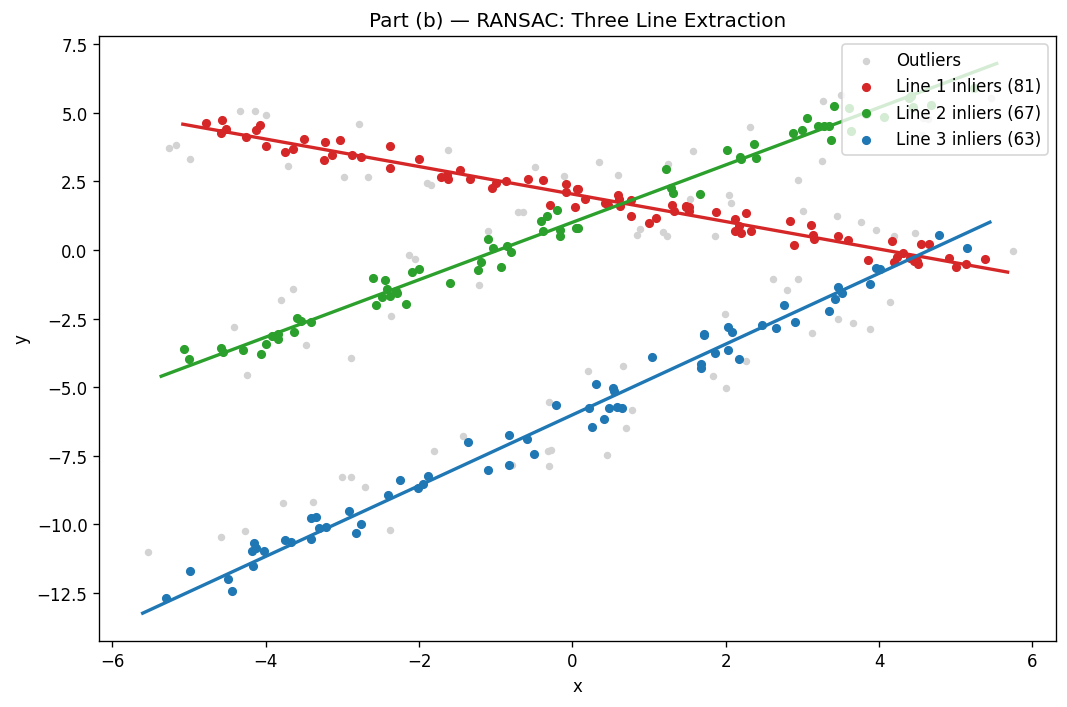

In [8]:
# ── Part (b) Visualization: Three RANSAC lines ──
colours = ['tab:red', 'tab:green', 'tab:blue']
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x_all[outlier_mask], y_all[outlier_mask],
           color='lightgray', s=12, label='Outliers', zorder=1)

for i, ((a_i, b_i, c_i), mask) in enumerate(zip(lines, inlier_masks)):
    xi, yi = x_all[mask], y_all[mask]
    ax.scatter(xi, yi, color=colours[i], s=20,
               label=f'Line {i+1} inliers ({mask.sum()})', zorder=2)
    if abs(b_i) > 1e-9:
        xs = np.linspace(xi.min() - 0.3, xi.max() + 0.3, 300)
        ax.plot(xs, (-a_i * xs - c_i) / b_i, color=colours[i], linewidth=2, zorder=3)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Part (b) — RANSAC: Three Line Extraction')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('q1b_ransac_lines.png', dpi=150)
print('Saved → q1b_ransac_lines.png')
plt.show()